# BCSC Risk Factors Dataset XGBoost Breast Cancer Risk Model

Author: Alexandros Papadopoulos

This companion notebook for *"Developing an XGBoost model for breast cancer risk prediction in women"*
(BCSC Risk Factors Dataset, 2013-2017 subset) should allow anyone to fully replicate the results presented in the thesis.

**Before running:** download the three BCSC Risk Factors Dataset zip files from
[bcsc-research.org](https://www.bcsc-research.org/index.php/datasets/rf/risk-factor-dataset-download)
(no login required), unzip them, and place the three CSVs in the same folder as this notebook:

```
bcsc_risk_factors_summarized1_092020.csv
bcsc_risk_factors_summarized2_092020.csv
bcsc_risk_factors_summarized3_092020.csv
```

If your filenames differ, edit `CSV_FILES` in the cell below.

Run the cells top to bottom. Section 3 (bootstrap validation) will take longer than everything else, otherwise all cells should take less than a minute to execute.

In [3]:
# If you haven't installed dependencies yet, uncomment and run:
# %pip install pandas numpy xgboost==3.2.0 scikit-learn shap==0.51.0 matplotlib pyarrow

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression

plt.rcParams.update({'font.size': 11})
print("xgboost", xgb.__version__, "| shap", shap.__version__)

xgboost 3.2.0 | shap 0.51.0


## 1. Data preparation

This cell loads the three BCSC Risk Factors Dataset CSV files, filters to the 2013–2017 study window, and prepares the data for model training. 
Rows where the outcome variable (`breast_cancer_history`) is coded as 9 (unknown) are removed, as these cannot be used for supervised learning. 
The sentinel code 9 (used across multiple predictor columns to indicate unknown values) is recoded to `NaN` to allow XGBoost's built-in sparsity-aware split-finding mechanism to handle missing values natively without imputation. The two nominal (unordered) predictors — `race_eth` and `menopaus` — are cast to pandas `category` dtype before recoding, as performing the replacement first would force a floating-point conversion that XGBoost's categorical handling does not support.

In [4]:
# Load the dataset's .csv files
CSV_FILES = [
    "bcsc_risk_factors_summarized1_092020.csv",
    "bcsc_risk_factors_summarized2_092020.csv",
    "bcsc_risk_factors_summarized3_092020.csv",
]
# Use only rows where the year is between 2013 and 2017
YEAR_MIN, YEAR_MAX = 2013, 2017

# Per the BCSC Risk Factors Dataset Documentation: code 9 = "Unknown" for these columns.
# age_group_5_years has no unknown code (always observed at the index exam).
UNKNOWN_9_COLS = ["race_eth", "first_degree_hx", "age_menarche", "age_first_birth",
                   "BIRADS_breast_density", "current_hrt", "menopaus", "bmi_group",
                   "biophx", "breast_cancer_history"]
NOMINAL_COLS = ["race_eth", "menopaus"]

#Checks that all three CSVs are present in the folder. Otherwise, shows an error message.
missing = [p for p in CSV_FILES if not Path(p).exists()]
if missing:
    raise FileNotFoundError(f"Could not find: {missing}. Place the 3 BCSC CSVs next to this notebook.")

# Reads all three CSVs and stacks them into one single table.
df = pd.concat([pd.read_csv(p) for p in CSV_FILES], ignore_index=True)
df = df[(df.year >= YEAR_MIN) & (df.year <= YEAR_MAX)].copy()

# Records the total number of weighted women before the next filtering step, for documentation purposes.
n_weighted_before = int(df["count"].sum())
# Removes rows where the outcome is unknown
df = df[df.breast_cancer_history != 9].copy()
#Records the weighted total after that removal, to show how many women were removed due to unknown outcomes.
n_weighted_after = int(df["count"].sum())

# Nominal (unordered) columns: cast to category FIRST (categories stay plain int64),
# then drop the "9 = Unknown" category so it becomes a proper missing value. Doing
# replace(9, NaN) before astype("category") would force the categories to float64,
# which XGBoost's categorical split handling rejects outright.
for c in NOMINAL_COLS:
    df[c] = df[c].astype("category")
    df[c] = df[c].cat.remove_categories([9])

# Ordinal/numeric columns: plain NaN recode is fine, since these stay numeric.
for c in [c for c in UNKNOWN_9_COLS if c != "breast_cancer_history" and c not in NOMINAL_COLS]:
    df[c] = df[c].replace(9, np.nan)

# After all the filtering, row numbers may have gaps. This resets them to a clean 0, 1, 2, 3... sequence.
df = df.reset_index(drop=True)

# Prints original population size, population after removing entries with unknown outcomes, number of unique rows, number of events, and that the category dtypes are correct integers.
print(f"Weighted N, 2013-2017, before outcome filter: {n_weighted_before:,}")
print(f"Weighted N, after dropping unknown-outcome rows: {n_weighted_after:,}")
print(f"Rows (unique covariate patterns): {len(df):,}")
print(f"Weighted events (breast_cancer_history=1): {int(df.loc[df.breast_cancer_history==1,'count'].sum()):,}")
print(f"race_eth categories: {df['race_eth'].cat.categories.tolist()} (dtype: {df['race_eth'].cat.categories.dtype})")
print(f"menopaus categories: {df['menopaus'].cat.categories.tolist()} (dtype: {df['menopaus'].cat.categories.dtype})")

Weighted N, 2013-2017, before outcome filter: 2,271,644
Weighted N, after dropping unknown-outcome rows: 1,871,726
Rows (unique covariate patterns): 428,808
Weighted events (breast_cancer_history=1): 180,780
race_eth categories: [1, 2, 3, 4, 5, 6] (dtype: int64)
menopaus categories: [1, 2, 3] (dtype: int64)


In [5]:
# Missingness per predictor, weighted by count
total_w = df["count"].sum()
for c in [c for c in UNKNOWN_9_COLS if c != "breast_cancer_history"]:
    n_unknown = df.loc[df[c].isna(), "count"].sum()
    print(f"{c:25s} {n_unknown:>10,.0f}  ({n_unknown/total_w*100:5.2f}%)")

race_eth                      56,930  ( 3.04%)
first_degree_hx               30,087  ( 1.61%)
age_menarche                 945,474  (50.51%)
age_first_birth              386,178  (20.63%)
BIRADS_breast_density         53,108  ( 2.84%)
current_hrt                  105,826  ( 5.65%)
menopaus                      98,913  ( 5.28%)
bmi_group                    278,026  (14.85%)
biophx                        27,364  ( 1.46%)


## 2. Train XGBoost model and evaluate apparent performance

### 2.1. Training the XGBoost model

This cell defines the feature set, target variable, and sample weights, then trains the XGBoost model on the full 2013–2017 dataset. No train/test split is used, as the entire subset is used for development, with internal validation handled separately via bootstrap resampling in Section 3. Each row is weighted by its `count` value, so the model learns from the true population distribution rather than treating each unique covariate combination equally. Class imbalance is addressed through `scale_pos_weight`, calculated as the ratio of weighted negatives to weighted positives (9.354), which up-weights the minority class during training. The trained model is saved to `xgb_bcsc_model.json` for reproducibility, and apparent predicted probabilities are generated on the full dataset for use in the evaluation cells below.

In [6]:
# Defines which columns from the CSVs are the predictors, the outcome and the population counts
FEATURES = ["age_group_5_years", "race_eth", "first_degree_hx", "age_menarche",
            "age_first_birth", "BIRADS_breast_density", "current_hrt", "menopaus",
            "bmi_group", "biophx"]
TARGET = "breast_cancer_history"
WEIGHT = "count"

# Splits the table in three parts: input features, outcome labels (converted to integers 0/1), weights (converted to decimals)
X = df[FEATURES]
y = df[TARGET].astype(int)
w = df[WEIGHT].astype(float)

# Calculates total number of women without breast cancer (neg) and with breast cancer (pos)
neg, pos = w[y == 0].sum(), w[y == 1].sum()
scale_pos_weight = neg / pos
print(f"Weighted negatives: {neg:,.0f}  Weighted positives: {pos:,.0f}  scale_pos_weight={scale_pos_weight:.3f}")

# Sets the model's hyperparameters
XGB_PARAMS = dict(
    objective="binary:logistic", eval_metric="auc", max_depth=4, learning_rate=0.05,
    n_estimators=300, subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    enable_categorical=True, random_state=42, n_jobs=-1,
)

# Trains the model, adding to each covariant (row) weight by how many women they represent. A covariant with count=500 will affect the model's learning 500 times more than a row with count=1.
model = xgb.XGBClassifier(**XGB_PARAMS, scale_pos_weight=scale_pos_weight)
model.fit(X, y, sample_weight=w)

# Saves the trained model to a file so it can be reloaded later without retraining.
model.save_model("xgb_bcsc_model.json")

# Runs the trained model on the same data it was trained on to get predicted probabilities.
p_apparent = model.predict_proba(X)[:, 1]
print("Model trained and saved to xgb_bcsc_model.json")

Weighted negatives: 1,690,946  Weighted positives: 180,780  scale_pos_weight=9.354
Model trained and saved to xgb_bcsc_model.json


### 2.2 Apparent performance metrics

Before running bootstrap validation, we compute the model's *apparent* performance, its performance on the same data it was trained on. These figures are deliberately optimistic and will later be corrected for overfitting in Section 3.

Two metrics are computed:

- **AUC-ROC** (`weighted_auc`): Discrimination - the probability that the model ranks a positive case higher than a negative one. Weighted by `count` to reflect the number of women each row represents.

- **Calibration slope and intercept** (`calibration_slope_intercept`): Calibration - how well predicted probabilities match observed event rates. Computed via flexible (Cox) calibration: an unpenalized logistic regression of true outcomes on the logit  of predicted probabilities. A perfectly calibrated model has slope = 1.0 and  intercept = 0.0. The large negative intercept here is an expected artifact of `scale_pos_weight` and is addressed in Section 2.5.

In [7]:
# Adds the `count` column as weight for the AUC calculations to keep it consistent with the model's training
def weighted_auc(y_true, y_score, weights):
    return roc_auc_score(y_true, y_score, sample_weight=weights)

# Computes flexible calibration. 
def calibration_slope_intercept(y_true, y_score, weights):
    """Fit y ~ logit(p_hat) via weighted logistic regression (flexible/Cox calibration)."""
    eps = 1e-6
    p = np.clip(y_score, eps, 1 - eps)
    logit_p = np.log(p / (1 - p))
    lr = LogisticRegression(C=1e10, solver="lbfgs", max_iter=200)  # ~unpenalized
    lr.fit(logit_p.reshape(-1, 1), y_true, sample_weight=weights)
    return float(lr.coef_[0][0]), float(lr.intercept_[0]), logit_p

# Apparent predictions on the same data that the model was trained on. This is intentionally optimistic and will be corrected through Bootstrap Internal Validation.
auc_apparent = weighted_auc(y, p_apparent, w)
slope_apparent, intercept_apparent, logit_p = calibration_slope_intercept(y.values, p_apparent, w.values)

# Prints the results
print(f"Apparent AUC-ROC: {auc_apparent:.4f}")
print(f"Apparent calibration slope: {slope_apparent:.4f}, intercept: {intercept_apparent:.4f}")

Apparent AUC-ROC: 0.8968
Apparent calibration slope: 1.0361, intercept: -2.2509


### 2.3 ROC curve

The ROC curve plots sensitivity (true positive rate) against 1 - specificity (false positive rate) across all classification thresholds, weighted by `count`. The diagonal dashed line represents a random classifier (AUC = 0.500); the further the curve bows toward the top-left corner, the stronger the model's discrimination. The AUC shown is the apparent value computed in Section 2.2. The figure is saved to `fig_roc_curve.png`.

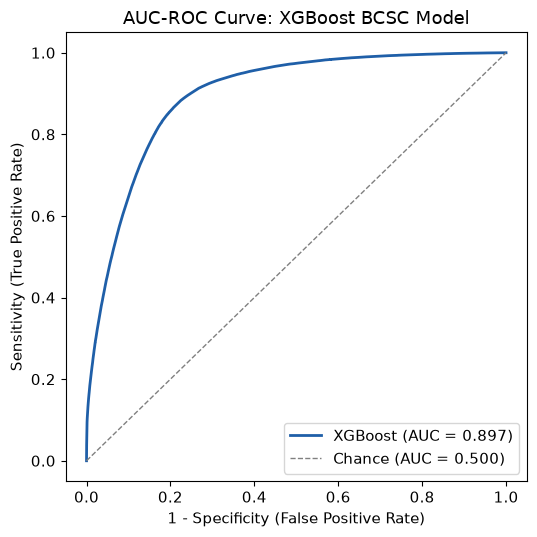

In [8]:
# Records all true positives and false positives across every possible classification and adds the same weight (w) as all other sections to the ROC curve.
fpr, tpr, _ = roc_curve(y, p_apparent, sample_weight=w)

# Designs the figure
plt.figure(figsize=(5.5, 5.5))
plt.plot(fpr, tpr, color="#1f5fa8", lw=2, label=f"XGBoost (AUC = {auc_apparent:.3f})")
plt.plot([0, 1], [0, 1], color="grey", lw=1, linestyle="--", label="Chance (AUC = 0.500)")
plt.xlabel("1 - Specificity (False Positive Rate)")
plt.ylabel("Sensitivity (True Positive Rate)")
plt.title("AUC-ROC Curve: XGBoost BCSC Model")
plt.legend(loc="lower right")
plt.tight_layout()

# Saves the figure in a PNG and shows the figure within the codebook.
plt.savefig("fig_roc_curve.png", dpi=200)
plt.show()

### 2.4 Calibration plot (raw)

Calibration is assessed by grouping predictions into ten deciles of predicted risk 
and comparing the mean predicted probability in each decile against the observed 
event rate, both weighted by `count`. Points falling on the diagonal indicate perfect 
calibration. The model is expected to be overpredicting due to `scale_pos_weight` shifting the model's probability baseline upward 
during training. The calibration *slope* (≈ 1.04) from 2.2 confirms that the model spreads risk 
correctly; only the intercept offset is problematic, and it is corrected in Section 2.5.
The figure is saved to `fig_calibration_plot.png`.

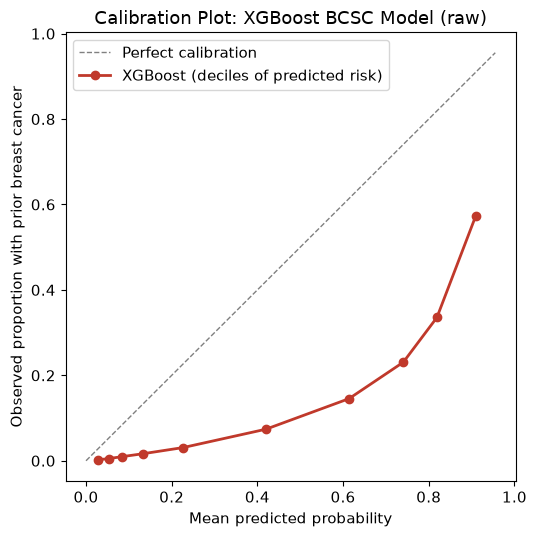

,decile,mean_pred,obs_rate
0,0,0.028468,0.002288
1,1,0.053419,0.005167
2,2,0.084584,0.009705
3,3,0.132221,0.016363
4,4,0.226860,0.030947
5,5,0.419972,0.073886
6,6,0.613913,0.145430
7,7,0.740634,0.230774
8,8,0.819083,0.335492
9,9,0.909783,0.573419


In [9]:
#Groups predictions in 10 deciles by predicted probability and, for each decile, calculates the average predicted probability and the average observed outcome rate.
def decile_calibration(pred, y_true, weights):
    tmp = pd.DataFrame({"p": pred, "y": y_true, "w": weights})
    tmp["decile"] = pd.qcut(tmp["p"], 10, labels=False, duplicates="drop")
    return tmp.groupby("decile").apply(lambda d: pd.Series({
        "mean_pred": np.average(d["p"], weights=d["w"]),
        "obs_rate": np.average(d["y"], weights=d["w"]),
    })).reset_index()

# Runs the function on the raw, uncorrected predictions
cal = decile_calibration(p_apparent, y.values, w.values)

# Designs the figure
plt.figure(figsize=(5.5, 5.5))
plt.plot([0, cal["mean_pred"].max() * 1.05], [0, cal["mean_pred"].max() * 1.05],
          color="grey", lw=1, linestyle="--", label="Perfect calibration")
plt.plot(cal["mean_pred"], cal["obs_rate"], marker="o", color="#c0392b", lw=2,
          label="XGBoost (deciles of predicted risk)")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed proportion with prior breast cancer")
plt.title("Calibration Plot: XGBoost BCSC Model (raw)")
plt.legend(loc="upper left")
plt.tight_layout()

# Saves the figure in a PNG and shows the figure within the codebook.
plt.savefig("fig_calibration_plot.png", dpi=200)
plt.show()
cal

### 2.5 Calibration plot (recalibrated)
Logistic recalibration is applied by rescaling the model's log-odds predictions 
using the calibration slope and intercept estimated in Section 2.2, then converting 
back to probabilities via the sigmoid function. This corrects the intercept offset 
introduced by `scale_pos_weight`, re-anchoring predicted probabilities to the true 
observed prevalence (~9.66%). The decile calibration plot is then repeated on the 
recalibrated predictions. Points should now fall close to the diagonal, indicating 
that predicted risk aligns with observed event rates across the full risk spectrum. 
The figure is saved to `fig_calibration_plot_recalibrated.png`.

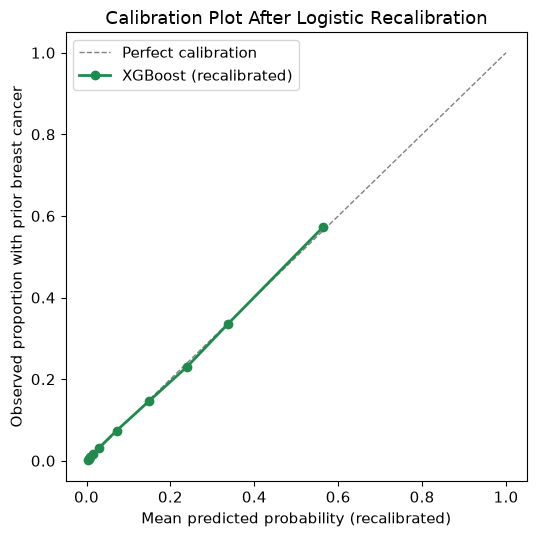

,decile,mean_pred,obs_rate
0,0,0.002721,0.002288
1,1,0.005337,0.005167
2,2,0.008864,0.009705
3,3,0.014822,0.016363
4,4,0.029075,0.030947
5,5,0.071707,0.073886
6,6,0.148144,0.145430
7,7,0.239881,0.230774
8,8,0.337298,0.335492
9,9,0.564500,0.573419


In [ ]:
# Rescales the logit from the 2.2 predictions using the calibration slope and intercept, and converts it back to probability.
p_recal = 1 / (1 + np.exp(-(slope_apparent * logit_p + intercept_apparent)))
cal_recal = decile_calibration(p_recal, y.values, w.values)

# Designs the figure
plt.figure(figsize=(5.5, 5.5))
plt.plot([0, 1], [0, 1], color="grey", lw=1, linestyle="--", label="Perfect calibration")
plt.plot(cal_recal["mean_pred"], cal_recal["obs_rate"], marker="o", color="#1f8a4c", lw=2,
          label="XGBoost (recalibrated)")
plt.xlabel("Mean predicted probability (recalibrated)")
plt.ylabel("Observed proportion with prior breast cancer")
plt.title("Calibration Plot After Logistic Recalibration")
plt.legend(loc="upper left")
plt.tight_layout()

# Saves the figure in a PNG and shows the figure within the codebook. Displays `mean_pred` and `obs_rate`.`
plt.savefig("fig_calibration_plot_recalibrated.png", dpi=200)
plt.show()
cal_recal

## 3. Model Validation

### 3.1 Bootstrap Internal Validation

Optimism-corrected bootstrap validation following Harrell's method. For each of 
B = 200 bootstrap iterations, a new XGBoost model is trained on a bootstrap resample 
(rows drawn with replacement from the full dataset) and evaluated twice: once on the 
bootstrap sample itself (`auc_boot_train`) and once on the original full dataset 
(`auc_boot_test`). The difference between the two is the *optimism* for that 
iteration, how much the model overestimates its performance by being tested on its own training data.

Mean optimism across all 200 iterations is subtracted from the apparent AUC and 
calibration slope to produce optimism-corrected estimates. A 95% confidence interval 
is derived from the 2.5th and 97.5th percentiles of the boot-test AUC distribution. 
Results are saved incrementally to `bootstrap_results.csv`; re-running this cell after 
an interruption resumes from the last completed iteration.

In [11]:
# Number of bootstrap iterations. Reduce for a faster/rougher estimate
B = 200  

# Checkpoint/resume logic. Results are saved incrementally, so if the kernel crashes mid-run, it picks up from where it left off rather than starting over.
out_path = Path("bootstrap_results.csv")
done_iters = set()
if out_path.exists():
    done_iters = set(pd.read_csv(out_path)["iter"].tolist())
    print(f"Resuming: {len(done_iters)} iterations already completed.")

# Total number of rows in the data set. `rows` is an empty list that will collect results from each iteration.
n = len(df)
rows = []

# Loop from 0 to 199. If this iteration number was already saved in the CSV from a previous run, skip it.
for b in range(B):
    if b in done_iters:
        continue
    # Creates a random number generator so each bootstrap is reproducible. 
    rng = np.random.default_rng(1000 + b)
    # Allows the bootstrap to draw random rows with replacement for the validation.
    boot_idx = rng.integers(0, n, size=n)
    # Uses indices to slice out the bootstrap sample.    
    Xb, yb, wb = X.iloc[boot_idx], y.iloc[boot_idx], w.iloc[boot_idx]
    # Trains a brand new model on the bootstrap sample using the exact same hyperparameters as the main model.
    mb = xgb.XGBClassifier(**XGB_PARAMS, scale_pos_weight=scale_pos_weight)
    mb.fit(Xb, yb, sample_weight=wb)
    # Generates two prediction sets from the same bootstrap model. The trained, optimistic one and the new, realistic one.
    p_bb = mb.predict_proba(Xb)[:, 1]
    p_bo = mb.predict_proba(X)[:, 1]
    # Computes AUC and calibration slope for both sets.
    auc_bt = weighted_auc(yb, p_bb, wb)
    auc_bo = weighted_auc(y, p_bo, w)
    s_bt, _, _ = calibration_slope_intercept(yb.values, p_bb, wb.values)
    s_bo, _, _ = calibration_slope_intercept(y.values, p_bo, w.values)
    # Saves the four numbers for this iteration into the `rows` list as a dictionary.
    rows.append({"iter": b, "auc_boot_train": auc_bt, "auc_boot_test": auc_bo,
                  "slope_boot_train": s_bt, "slope_boot_test": s_bo})
    # Every 10 iterations prints a progress update, flushes the accumulated rows to the CSV file, then clear rows to free memory.
    if (b + 1) % 10 == 0:
        print(f"  iter {b}: auc_test={auc_bo:.4f}  slope_test={s_bo:.4f}")
        pd.DataFrame(rows).to_csv(out_path, mode="a", header=not out_path.exists(), index=False)
        rows = []
        
# After the loop ends, writes any remaining rows that didn't land on a multiple of 10.
if rows:
    pd.DataFrame(rows).to_csv(out_path, mode="a", header=not out_path.exists(), index=False)

print("Bootstrap complete.")

Resuming: 200 iterations already completed.
Bootstrap complete.


### 3.2 Results Summary

Reads the 200 iterations saved to `bootstrap_results.csv` and computes the final 
validated performance estimates. For each iteration, the difference between boot-train 
and boot-test AUC represents the optimism introduced by testing a model on its own 
training data. The mean optimism across all 200 iterations (0.0012) is subtracted from 
the apparent AUC to produce the optimism-corrected AUC (0.8956). The 95% confidence 
interval [0.8962, 0.8966] is derived from the 2.5th and 97.5th percentiles of the 
boot-test AUC distribution. The same correction is applied to the calibration slope 
(corrected: 1.0289). The negligible optimism and tight confidence interval indicate 
that the model is highly stable and generalises well to unseen data.

In [49]:
# Load bootstrap results
boot_xgb = pd.read_csv("bootstrap_results.csv")

# Optimism correction — AUC
opt_xgb_auc      = (boot_xgb["auc_boot_train"] - boot_xgb["auc_boot_test"]).mean()
auc_corrected     = auc_apparent - opt_xgb_auc
corr_per_boot_xgb = auc_apparent - (boot_xgb["auc_boot_train"] - boot_xgb["auc_boot_test"])
ci_xgb            = np.percentile(corr_per_boot_xgb, [2.5, 97.5])

# Optimism correction — calibration slope
opt_xgb_slope  = (boot_xgb["slope_boot_train"] - boot_xgb["slope_boot_test"]).mean()
slope_corrected = slope_apparent - opt_xgb_slope

print(f"=== Optimism-corrected internal validation (B={len(boot_xgb)}) ===")
print(f"Apparent AUC:                          {auc_apparent:.4f}")
print(f"Mean optimism (AUC):                   {opt_xgb_auc:.4f}")
print(f"Optimism-corrected AUC:                {auc_corrected:.4f}")
print(f"Bootstrap-test 95% CI:                 [{ci_xgb[0]:.4f}, {ci_xgb[1]:.4f}]")
print(f"Apparent calibration slope:            {slope_apparent:.4f}")
print(f"Optimism-corrected calibration slope:  {slope_corrected:.4f}")

=== Optimism-corrected internal validation (B=200) ===
Apparent AUC:                          0.8968
Mean optimism (AUC):                   0.0012
Optimism-corrected AUC:                0.8956
Bootstrap-test 95% CI:                 [0.8938, 0.8971]
Apparent calibration slope:            1.0361
Optimism-corrected calibration slope:  1.0289


## 4. SHAP interpretability

SHAP (SHapley Additive exPlanations) values are computed to assess the contribution 
of each predictor to individual risk predictions. Rather than reporting a single 
global importance score per feature, SHAP assigns each predictor a value for each 
observation that reflects its directional impact on the model output: positive values 
push predicted risk upward, negative values push it downward.

To keep runtime reasonable while preserving population representativeness, SHAP values 
are computed on a weighted random sample of 50,000 rows drawn proportional to the 
BCSC `count` column, rather than on all ~429,000 unique covariate patterns. The 
summary plot shows the top 10 features ranked by mean absolute SHAP value, with point 
colour indicating the feature value (red = high, blue = low) and horizontal position 
indicating the direction and magnitude of the effect. Grey points indicate missing values.

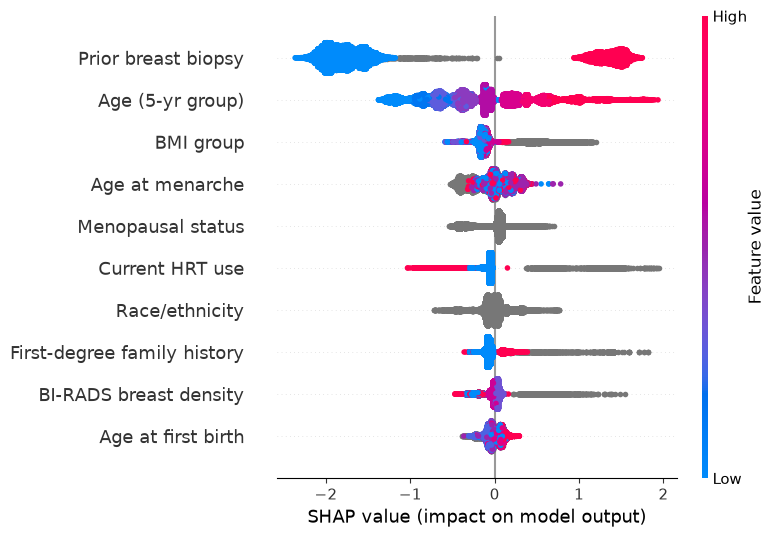

In [13]:
# Tested with: xgboost==3.2.0, shap==0.51.0, Python 3.11.7
# Note: SHAP <0.51.0 is incompatible with XGBoost 3.x due to bracket
# notation used for base_score in saved model files.

# Sets sample size and column names to be human-readable for the figure's plot axes.
SAMPLE_SIZE = 50_000
LABELS = {
    "age_group_5_years": "Age (5-yr group)",
    "race_eth": "Race/ethnicity",
    "first_degree_hx": "First-degree family history",
    "age_menarche": "Age at menarche",
    "age_first_birth": "Age at first birth",
    "BIRADS_breast_density": "BI-RADS breast density",
    "current_hrt": "Current HRT use",
    "menopaus": "Menopausal status",
    "bmi_group": "BMI group",
    "biophx": "Prior breast biopsy",
}

# Draws 50.000 rows at random, but weighted by `count` so the sample remains representative of the actual population.
rng = np.random.default_rng(42)
probs = df["count"].values / df["count"].values.sum()
sample_idx = rng.choice(len(df), size=SAMPLE_SIZE, replace=True, p=probs)
X_shap = df[FEATURES].iloc[sample_idx].rename(columns=LABELS)

# Restores category dtypes lost during rename
X_shap["Race/ethnicity"] = X_shap["Race/ethnicity"].astype("category")
X_shap["Menopausal status"] = X_shap["Menopausal status"].astype("category")

# Wraps the data in XGBoost's native format and explicitly tells it to handle categorical columns. Without this, SHAP cannot function.
dmat = xgb.DMatrix(X_shap, enable_categorical=True)

# Creates the explainer using the trained model and its booster. 
explainer = shap.TreeExplainer(model.get_booster(), feature_perturbation="tree_path_dependent")
shap_values = explainer.shap_values(dmat, check_additivity=False)

# Designs the SHAP plot
shap.summary_plot(shap_values, X_shap, max_display=10, show=False)
plt.tight_layout()
plt.savefig("fig_shap_summary.png", dpi=200, bbox_inches="tight")
plt.show()

In [14]:
# Takes the absolute value of every SHAP value, then averages across all 50,000 sampled rows. The resulting value is used to determine the predictor's impact.
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Wraps the values of the predictors in ranked order.
importance = pd.Series(mean_abs_shap, index=X_shap.columns).sort_values(ascending=False)

# Saves the ranked table to a CSV for easy reference.
importance.to_csv("shap_feature_importance.csv", header=["mean_abs_shap"])

# Displays the ranked table in the notebook.
importance

Prior breast biopsy            1.668256
Age (5-yr group)               0.530354
BMI group                      0.192310
Age at menarche                0.180987
Menopausal status              0.150031
Current HRT use                0.124378
Race/ethnicity                 0.094906
First-degree family history    0.094140
BI-RADS breast density         0.078024
Age at first birth             0.075554
dtype: float32

## 5. Comparison with other models

To contextualise the XGBoost model's performance, two alternative models are trained on the same data using an identical weighting, class-imbalance handling, and bootstrap validation procedure: a Logistic Regression baseline and a Random Forest ensemble. Several other candidate models were considered but ultimately excluded due to specific characteristics or known weaknesses. Naïve Bayes assumes conditional independence between predictors, a assumption clearly violated by the correlations among age, BMI, menopausal status, and HRT use in this dataset. K-Nearest Neighbours is computationally intractable at 428,808 rows and cannot handle sample weights meaningfully. Support Vector Machines do not produce calibrated probabilities natively and do not scale to this dataset size without approximations that would undermine a fair comparison.

### 5.1.1 Logistic Regression - Apparent AUC

Logistic Regression serves as the linear baseline. Because it cannot use pandas `category` dtype natively, the two nominal predictors (`race_eth` and `menopaus`) are one-hot encoded via a `ColumnTransformer`, and remaining missing values are filled with a sentinel value of −1, which falls outside all valid ordinal codes. Class imbalance is addressed using `class_weight={0: 1, 1: scale_pos_weight}`, mirroring the `scale_pos_weight` parameter used in XGBoost. The model is fitted with L2 regularisation (C = 1.0) using the lbfgs solver. Apparent weighted AUC on the full training data is **0.8685**, with a calibration slope of 1.0001 and intercept of −2.2297 — the near-zero slope indicates that Logistic Regression's predicted probabilities are already well-spread, with only an intercept offset introduced by class weighting. Logistic recalibration is then applied using the same Cox calibration approach from Section 2, correcting the intercept shift.

In [ ]:
from sklearn.linear_model import LogisticRegression as LR
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Encodes categoricals - XGBoost handled NaN natively, LR needs numeric input
cat_cols = ["race_eth", "menopaus"]
num_cols = [c for c in FEATURES if c not in cat_cols]

preprocessor = ColumnTransformer([
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ("pass", "passthrough", num_cols),
])

X_lr = X.copy()
for c in cat_cols:
    X_lr[c] = X_lr[c].astype(str).fillna("Unknown").replace("nan", "Unknown")
for c in num_cols:
    X_lr[c] = X_lr[c].fillna(-1)  # -1 is outside all valid ordinal codes

X_lr_enc = preprocessor.fit_transform(X_lr)

# Training - class_weight mirrors XGBoost's scale_pos_weight
lr_model = LR(C=1.0, solver="lbfgs", max_iter=1000,
              class_weight={0: 1, 1: scale_pos_weight})
lr_model.fit(X_lr_enc, y, sample_weight=w)

# Apparent performance
p_lr_apparent = lr_model.predict_proba(X_lr_enc)[:, 1]
auc_lr_apparent = weighted_auc(y, p_lr_apparent, w)
slope_lr, intercept_lr, logit_lr = calibration_slope_intercept(y, p_lr_apparent, w)
p_lr_recal = 1 / (1 + np.exp(-(slope_lr * logit_lr + intercept_lr)))

print(f"LR apparent AUC:          {auc_lr_apparent:.4f}")
print(f"LR calibration slope:     {slope_lr:.4f}")
print(f"LR calibration intercept: {intercept_lr:.4f}")

LR apparent AUC:          0.8685
LR calibration slope:     1.0001
LR calibration intercept: -2.2297


### 5.1.2 Logistic Regression - Bootstrap Validation and optimism correction

Bootstrap internal validation (B = 200) follows the same Harrell optimism-correction procedure used for XGBoost in Section 3. In each iteration, a new Logistic Regression model is trained on a bootstrap resample of the preprocessed encoded matrix (X_lr_enc) and evaluated on both the bootstrap sample and the original full dataset. The difference in AUC between the two evaluations estimates the optimism for that iteration. Mean optimism across all 200 iterations is subtracted from the apparent AUC to yield the optimism-corrected AUC of 0.8684 (95% CI: 0.8661–0.8706), and the same correction is applied to the calibration slope, yielding 0.9995. The negligible optimism (apparent AUC 0.8685 vs corrected 0.8684) and near-unity calibration slope confirm that Logistic Regression is not overfitting to the training data: its in-sample and out-of-sample performance are essentially identical.

In [52]:
B = 200
lr_boot_path = Path("bootstrap_lr_results.csv")
done_lr = set()
if lr_boot_path.exists():
    done_lr = set(pd.read_csv(lr_boot_path)["iter"].tolist())
    print(f"Resuming LR bootstrap: {len(done_lr)} iterations already completed.")

lr_rows = []
n = len(df)

for b in range(B):
    if b in done_lr:
        continue
    rng = np.random.default_rng(b)
    idx = rng.integers(0, n, size=n)

    X_b, y_b, w_b = X_lr_enc[idx], y.values[idx], w.values[idx]

    m = LR(C=1.0, solver="lbfgs", max_iter=1000,
           class_weight={0: 1, 1: scale_pos_weight})
    m.fit(X_b, y_b, sample_weight=w_b)

    p_train = m.predict_proba(X_b)[:, 1]
    p_test  = m.predict_proba(X_lr_enc)[:, 1]

    auc_train = weighted_auc(y_b, p_train, w_b)
    auc_test  = weighted_auc(y, p_test, w)
    sl_train, _, _ = calibration_slope_intercept(y_b, p_train, w_b)
    sl_test,  _, _ = calibration_slope_intercept(y,  p_test,  w)

    lr_rows.append({"iter": b, "auc_boot_train": auc_train, "auc_boot_test": auc_test,
                    "slope_boot_train": sl_train, "slope_boot_test": sl_test})

    if (b + 1) % 10 == 0:
        print(f"  LR bootstrap {b+1}/{B}")
        tmp = pd.DataFrame(lr_rows)
        if lr_boot_path.exists():
            tmp = pd.concat([pd.read_csv(lr_boot_path), tmp], ignore_index=True)
        tmp.to_csv(lr_boot_path, index=False)
        lr_rows = []

if lr_rows:
    tmp = pd.DataFrame(lr_rows)
    if lr_boot_path.exists():
        tmp = pd.concat([pd.read_csv(lr_boot_path), tmp], ignore_index=True)
    tmp.to_csv(lr_boot_path, index=False)

# Optimism correction
boot_lr = pd.read_csv(lr_boot_path)
opt_lr_auc    = (boot_lr["auc_boot_train"] - boot_lr["auc_boot_test"]).mean()
auc_lr_corr   = auc_lr_apparent - opt_lr_auc
corr_per_boot_lr = auc_lr_apparent - (boot_lr["auc_boot_train"] - boot_lr["auc_boot_test"])
ci_lr         = np.percentile(corr_per_boot_lr, [2.5, 97.5])
opt_lr_slope  = (boot_lr["slope_boot_train"] - boot_lr["slope_boot_test"]).mean()
slope_lr_corr = slope_lr - opt_lr_slope

print(f"\nLR optimism-corrected AUC: {auc_lr_corr:.4f}  (95% CI: {ci_lr[0]:.4f}–{ci_lr[1]:.4f})")
print(f"LR corrected cal. slope:   {slope_lr_corr:.4f}")

Resuming LR bootstrap: 200 iterations already completed.

LR optimism-corrected AUC: 0.8684  (95% CI: 0.8661–0.8706)
LR corrected cal. slope:   0.9995


### 5.2.1 Random Forest - Apparent AUC

A Random Forest classifier is trained using 100 fully grown trees (max_depth=None) on the same one-hot encoded feature matrix (X_lr_enc) used for Logistic Regression. Class imbalance is handled identically, via class_weight={0: 1, 1: scale_pos_weight}. Apparent weighted AUC on the full training data is 0.9305, markedly higher than both Logistic Regression (0.8685) and XGBoost (0.8968). This is expected: fully grown trees memorise their training samples, and apparent performance on training data reflects this overfitting rather than true generalisability. The apparent calibration slope is 1.0876 with intercept −2.3328; logistic recalibration is applied to correct the intercept offset before performing the final comparison.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    class_weight={0: 1, 1: scale_pos_weight},
    n_jobs=-1,
    random_state=42,
)
rf_model.fit(X_lr_enc, y, sample_weight=w)

# Apparent performance
p_rf_apparent = rf_model.predict_proba(X_lr_enc)[:, 1]
auc_rf_apparent = weighted_auc(y, p_rf_apparent, w)
slope_rf, intercept_rf, logit_rf = calibration_slope_intercept(y, p_rf_apparent, w)
p_rf_recal = 1 / (1 + np.exp(-(slope_rf * logit_rf + intercept_rf)))

print(f"RF apparent AUC:          {auc_rf_apparent:.4f}")
print(f"RF calibration slope:     {slope_rf:.4f}")
print(f"RF calibration intercept: {intercept_rf:.4f}")

RF apparent AUC:          0.9305
RF calibration slope:     1.0876
RF calibration intercept: -2.3328


### 5.2.2 Random Forest - Bootstrap Validation and optimism correction

Bootstrap internal validation (B = 200) reveals the full extent of Random Forest's overfitting. The optimism-corrected AUC drops to 0.8849 (95% CI: 0.8826–0.8871), a reduction of 0.0456 from the apparent value, by far the largest optimism of the three models. The corrected calibration slope is 0.5278, indicating severe over-dispersion of predicted probabilities: the model spreads risk too widely across the 0–1 scale, assigning excessively high probabilities to high-risk women and excessively low probabilities to low-risk women. This is an inherent property of the tree-averaging mechanism in Random Forests and cannot be remedied by logistic recalibration, which corrects only the intercept and slope linearly. In a clinical screening context, a calibration slope of 0.53 would substantially misrepresent individual risk levels even when discrimination is adequate.

In [ ]:
# Bootstrap validation
rf_boot_path = Path("bootstrap_rf_results.csv")
done_rf = set()
if rf_boot_path.exists():
    done_rf = set(pd.read_csv(rf_boot_path)["iter"].tolist())
    print(f"Resuming RF bootstrap: {len(done_rf)} iterations already completed.")

rf_rows = []

for b in range(B):
    if b in done_rf:
        continue
    rng = np.random.default_rng(b)
    idx = rng.integers(0, n, size=n)

    X_b, y_b, w_b = X_lr_enc[idx], y.values[idx], w.values[idx]

    m = RandomForestClassifier(
        n_estimators=100,
        class_weight={0: 1, 1: scale_pos_weight},
        n_jobs=-1,
        random_state=b,
    )
    m.fit(X_b, y_b, sample_weight=w_b)

    p_train = m.predict_proba(X_b)[:, 1]
    p_test  = m.predict_proba(X_lr_enc)[:, 1]

    auc_train = weighted_auc(y_b, p_train, w_b)
    auc_test  = weighted_auc(y, p_test, w)
    sl_train, _, _ = calibration_slope_intercept(y_b, p_train, w_b)
    sl_test,  _, _ = calibration_slope_intercept(y,  p_test,  w)

    rf_rows.append({"iter": b, "auc_boot_train": auc_train, "auc_boot_test": auc_test,
                    "slope_boot_train": sl_train, "slope_boot_test": sl_test})

    if (b + 1) % 10 == 0:
        print(f"  RF bootstrap {b+1}/{B}")
        tmp = pd.DataFrame(rf_rows)
        if rf_boot_path.exists():
            tmp = pd.concat([pd.read_csv(rf_boot_path), tmp], ignore_index=True)
        tmp.to_csv(rf_boot_path, index=False)
        rf_rows = []

if rf_rows:
    tmp = pd.DataFrame(rf_rows)
    if rf_boot_path.exists():
        tmp = pd.concat([pd.read_csv(rf_boot_path), tmp], ignore_index=True)
    tmp.to_csv(rf_boot_path, index=False)

# Optimism correction
boot_rf = pd.read_csv(rf_boot_path)
opt_rf_auc    = (boot_rf["auc_boot_train"] - boot_rf["auc_boot_test"]).mean()
auc_rf_corr   = auc_rf_apparent - opt_rf_auc
corr_per_boot_rf = auc_rf_apparent - (boot_rf["auc_boot_train"] - boot_rf["auc_boot_test"])
ci_rf         = np.percentile(corr_per_boot_rf, [2.5, 97.5])
opt_rf_slope  = (boot_rf["slope_boot_train"] - boot_rf["slope_boot_test"]).mean()
slope_rf_corr = slope_rf - opt_rf_slope

print(f"\nRF optimism-corrected AUC: {auc_rf_corr:.4f}  (95% CI: {ci_rf[0]:.4f}–{ci_rf[1]:.4f})")
print(f"RF corrected cal. slope:   {slope_rf_corr:.4f}")

Resuming RF bootstrap: 200 iterations already completed.

RF optimism-corrected AUC: 0.8849  (95% CI: 0.8826–0.8871)
RF corrected cal. slope:   0.5278


### 5.3 Final comparison

The table below summarises optimism-corrected AUC, 95% bootstrap confidence intervals, and corrected calibration slope for all three models. The ROC curves are plotted using recalibrated predicted probabilities; because recalibration preserves rank order, the curves reflect apparent discrimination. Corrected AUC values are shown in the legend alongside apparent values to allow direct comparison between what each model achieves on its training data and what it is expected to achieve on new data.

XGBoost achieves the best combination of discrimination and calibration among the three models. Its corrected AUC of 0.8956 represents only a marginal drop from apparent (Δ = 0.0012), indicating strong generalisation with minimal overfitting. Its corrected calibration slope of 1.0289 is the closest to the ideal value of 1.0, meaning predicted probabilities closely reflect true event rates after recalibration. Logistic Regression is competitive on discrimination (corrected AUC 0.8684) and near-perfectly calibrated (slope 0.9995), but its linear decision boundary limits its ability to capture non-linear interactions among predictors such as age, BMI, menopausal status, and HRT use. Random Forest shows the highest apparent AUC (0.9305) but the largest optimism gap (Δ = 0.0456) and a corrected calibration slope of 0.5278, which is clinically problematic: its predicted probabilities are over-dispersed and cannot be interpreted as reliable individual risk estimates. XGBoost is therefore selected as the final model for this study.

,Model,Apparent AUC,Corrected AUC,95% CI,Cal. slope (corrected)
0,Logistic Regression,0.8685,0.8684,"[0.8661, 0.8706]",0.9995
1,Random Forest,0.9305,0.8849,"[0.8826, 0.8871]",0.5278
2,XGBoost (this study),0.8968,0.8956,"[0.8938, 0.8971]",1.0289


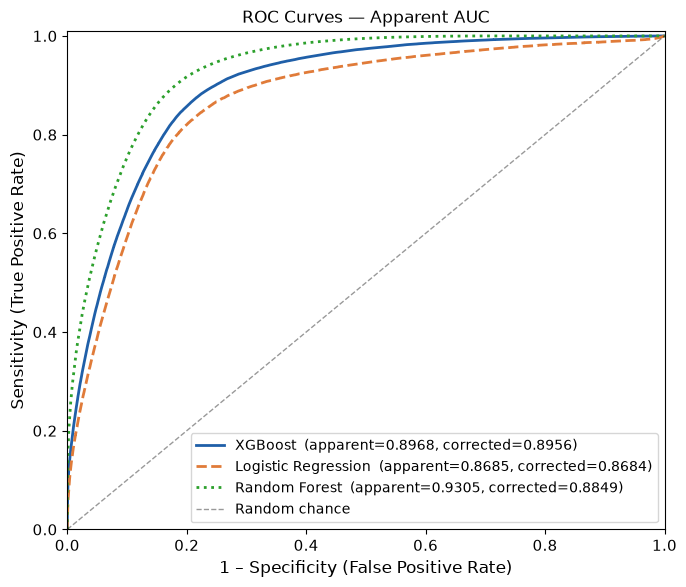

In [53]:
# Three-model comparison table
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost (this study)",
    ],
    "Apparent AUC": [
        f"{auc_lr_apparent:.4f}",
        f"{auc_rf_apparent:.4f}",
        f"{auc_apparent:.4f}",
    ],
    "Corrected AUC": [
        f"{auc_lr_corr:.4f}",
        f"{auc_rf_corr:.4f}",
        f"{auc_corrected:.4f}",
    ],
    "95% CI": [
        f"[{ci_lr[0]:.4f}, {ci_lr[1]:.4f}]",
        f"[{ci_rf[0]:.4f}, {ci_rf[1]:.4f}]",
        f"[{ci_xgb[0]:.4f}, {ci_xgb[1]:.4f}]",
    ],
    "Cal. slope (corrected)": [
        f"{slope_lr_corr:.4f}",
        f"{slope_rf_corr:.4f}",
        f"{slope_corrected:.4f}",
    ],
})

print()
display(comparison)

# AUC-ROC Curve comparison
fpr_xgb, tpr_xgb, _ = roc_curve(y, p_recal, sample_weight=w)
fpr_lr,  tpr_lr,  _ = roc_curve(y, p_lr_recal,      sample_weight=w)
fpr_rf,  tpr_rf,  _ = roc_curve(y, p_rf_recal,      sample_weight=w)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_xgb, tpr_xgb, color="#1f5fa8", lw=2,
        label=f"XGBoost  (apparent={auc_apparent:.4f}, corrected={auc_corrected:.4f})")
ax.plot(fpr_lr,  tpr_lr,  color="#e07b39", lw=2, linestyle="--",
        label=f"Logistic Regression  (apparent={auc_lr_apparent:.4f}, corrected={auc_lr_corr:.4f})")
ax.plot(fpr_rf,  tpr_rf,  color="#2ca02c", lw=2, linestyle=":",
        label=f"Random Forest  (apparent={auc_rf_apparent:.4f}, corrected={auc_rf_corr:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4, label="Random chance")

ax.set_xlabel("1 – Specificity (False Positive Rate)", fontsize=12)
ax.set_ylabel("Sensitivity (True Positive Rate)", fontsize=12)
ax.set_title("ROC Curves — Apparent AUC", fontsize=12)
ax.legend(loc="lower right", fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.01])
plt.tight_layout()
plt.savefig("roc_comparison.png", dpi=150)
plt.show()